# 16 — Coulomb Baseline: Physics Lower Bound for ESP Prediction

APBS solves the full Poisson-Boltzmann equation, accounting for:
- **Dielectric inhomogeneity**: ε_protein ≈ 2–4 vs ε_solvent ≈ 80
- **Ionic shielding**: Debye–Hückel screening from dissolved salt

Vacuum Coulomb ignores both effects and computes:

$$V(\mathbf{q}) = \sum_i \frac{q_i \cdot l_B^{\text{vac}}}{r_{iq}}$$

where $l_B^{\text{vac}} = e^2 / (4\pi\epsilon_0 k_B T) \approx 560$ Å at 298 K converts charge/distance to kT/e.
The $q_i$ are the PARSE partial charges already in every `.pqr` file — exactly what APBS takes as input.

**Why this matters for the thesis:**
- The RBF reconstruction (r ≈ 0.983) is an analytic *ceiling* — it reconstructs from APBS values directly.
- Vacuum Coulomb is a physics *floor* — same charge inputs, no PBE solver.
- The gap (Coulomb → GNN → ceiling) shows the model has learned to approximate solvation physics, not just raw charge–distance.

This is the final notebook in the staged ablation study (07–15) — the comparison table at the end is filled in once the winning DistanceESPN/AttentionESPN configurations from Phases 1–4 have been trained and evaluated.

In [1]:
import os
os.environ.setdefault("DISPLAY", ":0")
os.environ.setdefault("WAYLAND_DISPLAY", "wayland-0")
os.environ.setdefault("XDG_RUNTIME_DIR", "/mnt/wslg/runtime-dir")

'/run/user/1000/'

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

PROJECT_ROOT = Path("../..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import get_config, get_data_root
from src.utils.paths import ProteinPaths
from src.utils.io import load_metadata, update_metadata
from src.utils.filter import get_protein_ids

cfg       = get_config()
data_root = get_data_root()
pd.set_option("display.float_format", "{:.4f}".format)
print("data_root:", data_root)

data_root: /home/skyle/external_protein_data


In [3]:
# ── Bjerrum length in vacuum at 298 K [Å] ─────────────────────────────────────
# e² / (4πε₀ · kBT)  — converts elementary-charge/Å to kT/e
BJERRUM_VACUUM = 560.0

# Minimum atom–query distance [Å] to clamp before division (avoids PQR-atom singularities)
R_MIN = 0.5

# Chunked evaluation: number of query points per chunk (trades RAM for speed)
CHUNK_SIZE = 512

# Set True to write coulomb_pearson_r / coulomb_rmse to each protein's metadata JSON
WRITE_METADATA = False

# Protein to use for the single-protein walkthrough (change as needed)
all_ids = get_protein_ids(data_root, select_all=True)
SAMPLE_ID = all_ids[0]
print(f"Sample protein : {SAMPLE_ID}")
print(f"Total proteins : {len(all_ids)}")

Sample protein : AF-A0A011QK89-F1
Total proteins : 8461


In [4]:
def parse_pqr(pqr_path: Path):
    """
    Read PQR → atom_pos (N,3) float32, atom_charges (N,) float32.
    PDB2PQR output convention: last 5 fields per ATOM/HETATM are x y z charge radius.
    """
    positions, charges = [], []
    with open(pqr_path) as f:
        for line in f:
            if not line.startswith(("ATOM", "HETATM")):
                continue
            parts = line.split()
            if len(parts) < 5:
                continue
            x, y, z = float(parts[-5]), float(parts[-4]), float(parts[-3])
            charge   = float(parts[-2])
            positions.append([x, y, z])
            charges.append(charge)
    return np.array(positions, dtype=np.float32), np.array(charges, dtype=np.float32)


def coulomb_potential(query_pos, atom_pos, atom_charges, chunk_size=CHUNK_SIZE):
    """
    V(q) [kT/e] = Σ_i  q_i · BJERRUM_VACUUM / r_iq
    Evaluated in chunks to bound peak RAM for large proteins.
    """
    N_q = len(query_pos)
    V   = np.zeros(N_q, dtype=np.float64)
    for start in range(0, N_q, chunk_size):
        end  = min(start + chunk_size, N_q)
        diff = query_pos[start:end, np.newaxis, :] - atom_pos[np.newaxis, :, :]  # (chunk, N_a, 3)
        r    = np.linalg.norm(diff, axis=-1)   # (chunk, N_a)
        np.clip(r, R_MIN, None, out=r)
        V[start:end] = (atom_charges[np.newaxis, :] / r).sum(axis=-1) * BJERRUM_VACUUM
    return V.astype(np.float32)


def compute_metrics(pred, true):
    """Return (pearson_r, rmse) for 1-D arrays."""
    r, _  = pearsonr(pred.astype(float), true.astype(float))
    rmse  = float(np.sqrt(np.mean((pred - true) ** 2)))
    return float(r), rmse


print("Helper functions defined.")

Helper functions defined.


---
## Single Protein Walkthrough

Load PQR (charges) + `_esp.npz` (query positions + APBS ground truth), then evaluate.

In [5]:
p = ProteinPaths(SAMPLE_ID, data_root)

# ── PQR → atom positions + PARSE partial charges ───────────────────────────────
atom_pos, atom_charges = parse_pqr(p.pqr_path)
print(f"Atoms          : {len(atom_pos):>6}")
print(f"Net charge [e] : {atom_charges.sum():>8.2f}")
print(f"Charge range   : [{atom_charges.min():.3f}, {atom_charges.max():.3f}]")

# ── ESP file → query positions + APBS ground truth ────────────────────────────
esp_data  = np.load(p.esp_path)
verts     = esp_data["verts"]      # (N_v, 3) all mesh vertices
esp_verts = esp_data["esp_verts"]  # (N_v,)   APBS ESP at every vertex [kT/e]
query_idx = esp_data["query_idx"]  # (N_q,)   curvature-sampled indices

query_pos  = verts[query_idx]      # (N_q, 3)
true_esp   = esp_verts[query_idx]  # (N_q,)   ground truth at query points

print(f"\nMesh vertices  : {len(verts):>6}")
print(f"Query points   : {len(query_idx):>6}  ({100*len(query_idx)/len(verts):.1f}% of mesh)")
print(f"APBS ESP range : [{true_esp.min():.2f}, {true_esp.max():.2f}] kT/e")

Atoms          :   5713
Net charge [e] :    -1.00
Charge range   : [-0.780, 0.550]

Mesh vertices  :  42527
Query points   :   2126  (5.0% of mesh)
APBS ESP range : [-10.05, 54.62] kT/e


In [6]:
coulomb_esp = coulomb_potential(query_pos, atom_pos, atom_charges)
r, rmse = compute_metrics(coulomb_esp, true_esp)

print(f"Coulomb baseline — {SAMPLE_ID}")
print(f"  Pearson r : {r:.4f}")
print(f"  RMSE      : {rmse:.4f} kT/e")
print(f"  ESP range (pred) : [{coulomb_esp.min():.2f}, {coulomb_esp.max():.2f}]")

# Compare to RBF baseline from metadata
try:
    meta = load_metadata(SAMPLE_ID, data_root)
    rbf_r    = meta.get("pearson_r")
    rbf_rmse = meta.get("rmse")
    print(f"\n  RBF reconstruction : r={rbf_r:.4f}  RMSE={rbf_rmse:.4f} kT/e  (ceiling)")
    print(f"  Δr vs RBF          : {rbf_r - r:.4f}")
except Exception:
    pass

Coulomb baseline — AF-A0A011QK89-F1
  Pearson r : 0.5961
  RMSE      : 109.7076 kT/e
  ESP range (pred) : [-361.80, 397.48]


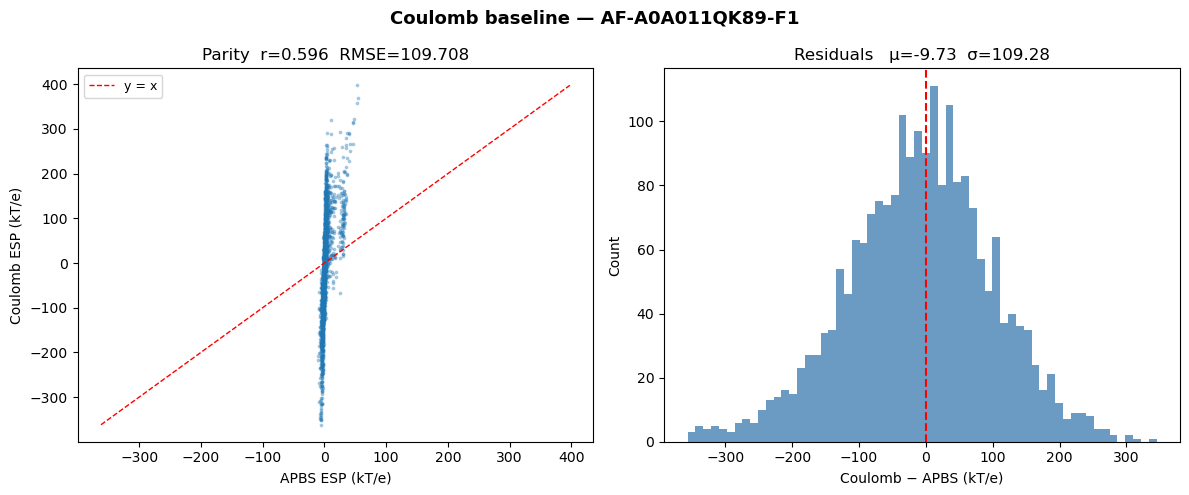

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Coulomb baseline — {SAMPLE_ID}", fontsize=13, fontweight="bold")

# ── Scatter: Coulomb vs APBS ───────────────────────────────────────────────────
ax = axes[0]
ax.scatter(true_esp, coulomb_esp, s=3, alpha=0.3, rasterized=True)
lo = min(true_esp.min(), coulomb_esp.min())
hi = max(true_esp.max(), coulomb_esp.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1, label="y = x")
ax.set_xlabel("APBS ESP (kT/e)")
ax.set_ylabel("Coulomb ESP (kT/e)")
ax.set_title(f"Parity  r={r:.3f}  RMSE={rmse:.3f}")
ax.legend(fontsize=9)

# ── Residuals distribution ─────────────────────────────────────────────────────
ax = axes[1]
residuals = coulomb_esp - true_esp
ax.hist(residuals, bins=60, color="steelblue", alpha=0.8, edgecolor="none")
ax.axvline(0, color="r", lw=1.5, linestyle="--")
ax.set_xlabel("Coulomb − APBS (kT/e)")
ax.set_ylabel("Count")
ax.set_title(f"Residuals   μ={residuals.mean():.2f}  σ={residuals.std():.2f}")

plt.tight_layout()
plt.show()

---
## Full Dataset Evaluation

Run Coulomb over every protein that has both a `.pqr` and an `_esp.npz`.

In [8]:
from concurrent.futures import ProcessPoolExecutor, as_completed

def _worker(pid):
    p = ProteinPaths(pid, data_root)
    if not p.pqr_path.exists() or not p.esp_path.exists():
        return None
    try:
        atom_pos_i, atom_charges_i = parse_pqr(p.pqr_path)
        esp_data_i  = np.load(p.esp_path)
        query_idx_i = esp_data_i["query_idx"]
        query_pos_i = esp_data_i["verts"][query_idx_i]
        true_esp_i  = esp_data_i["esp_verts"][query_idx_i]
        coulomb_i   = coulomb_potential(query_pos_i, atom_pos_i, atom_charges_i)
        r_i, rmse_i = compute_metrics(coulomb_i, true_esp_i)
        if WRITE_METADATA:
            update_metadata(pid, data_root=data_root,
                            data={"coulomb_pearson_r": round(r_i, 6),
                                  "coulomb_rmse":      round(rmse_i, 6)})
        row = {"protein_id": pid, "n_query": len(query_idx_i),
               "n_atoms": len(atom_pos_i), "coulomb_r": r_i, "coulomb_rmse": rmse_i}
        try:
            meta_i = load_metadata(pid, data_root)
            row["rbf_r"]    = meta_i.get("pearson_r")
            row["rbf_rmse"] = meta_i.get("rmse")
        except Exception:
            pass
        return row
    except Exception as e:
        return {"protein_id": pid, "error": str(e)}


N_WORKERS = 8  # tune to your core count

results, skipped = [], []
with ProcessPoolExecutor(max_workers=N_WORKERS) as pool:
    futures = {pool.submit(_worker, pid): pid for pid in all_ids}
    for fut in as_completed(futures):
        row = fut.result()
        if row is None or "error" in row:
            skipped.append(row)
        else:
            results.append(row)
            print(f"  {row['protein_id']:35s}  r={row['coulomb_r']:.4f}  RMSE={row['coulomb_rmse']:.4f}")

print(f"\nDone: {len(results)} evaluated, {len(skipped)} skipped.")

  AF-A0A0B4J1N3-F1                     r=0.9560  RMSE=384.1319
  AF-A0A0B0QJR1-F1                     r=0.8275  RMSE=280.0220
  AF-A0A0A7HIX1-F1                     r=0.8693  RMSE=112.0061
  AF-A0A0A7HIF0-F1                     r=0.8639  RMSE=159.9149
  AF-A0A023PYI2-F1                     r=0.9128  RMSE=101.1824
  AF-A0A023W0V9-F1                     r=0.9137  RMSE=154.8035
  AF-A0A023FT45-F1                     r=0.9292  RMSE=387.5865
  AF-A0A023PXF5-F1                     r=0.8338  RMSE=179.3170
  AF-A0A011QK89-F1                     r=0.5961  RMSE=109.7076
  AF-A0A023W163-F1                     r=0.9347  RMSE=192.0462
  AF-A0A075TR27-F1                     r=0.7437  RMSE=186.0084
  AF-A0A0C1E1C6-F1                     r=0.8293  RMSE=166.6813
  AF-A0A0D1DWQ2-F1                     r=0.8728  RMSE=132.1272
  AF-A0A0C1E5J2-F1                     r=0.8635  RMSE=226.9547
  AF-A0A0E3SVE7-F1                     r=0.9530  RMSE=282.9642
  AF-A0A0F5HNH9-F1                     r=0.9014  RMSE=4

In [13]:
df = pd.DataFrame(results)

print("=" * 55)
print("Coulomb baseline — dataset summary")
print("=" * 55)
print(f"  Pearson r   mean ± std : {df.coulomb_r.mean():.4f} ± {df.coulomb_r.std():.4f}")
print(f"              median     : {df.coulomb_r.median():.4f}")
print(f"              [min, max] : [{df.coulomb_r.min():.4f}, {df.coulomb_r.max():.4f}]")
print(f"  RMSE [kT/e] mean ± std : {df.coulomb_rmse.mean():.4f} ± {df.coulomb_rmse.std():.4f}")
print(f"              median     : {df.coulomb_rmse.median():.4f}")
print(f"              [min, max] : [{df.coulomb_rmse.min():.4f}, {df.coulomb_rmse.max():.4f}]")

if "rbf_r" in df.columns:
    valid_rbf = df.dropna(subset=["rbf_r"])
    print(f"\n  RBF ceiling (same proteins):")
    print(f"  Pearson r   mean ± std : {valid_rbf.rbf_r.mean():.4f} ± {valid_rbf.rbf_r.std():.4f}")
    print(f"  Gap (RBF − Coulomb)    : {(valid_rbf.rbf_r - valid_rbf.coulomb_r).mean():.4f}")

print()
display(df.sort_values("coulomb_r"))

Coulomb baseline — dataset summary
  Pearson r   mean ± std : 0.8648 ± 0.0774
              median     : 0.8790
              [min, max] : [0.4341, 0.9867]
  RMSE [kT/e] mean ± std : 226.7405 ± 108.9190
              median     : 193.3109
              [min, max] : [76.5258, 982.5012]

  RBF ceiling (same proteins):
  Pearson r   mean ± std : nan ± nan
  Gap (RBF − Coulomb)    : nan



,protein_id,n_query,n_atoms,coulomb_r,coulomb_rmse,rbf_r,rbf_rmse
534,AF-A8JHB7-F1,3359,9073,0.4341,205.5196,None,None
1758,AF-O82784-F1,3014,8593,0.4445,445.5632,None,None
8150,AF-Q9V778-F1,3819,9917,0.4448,175.0262,None,None
297,AF-A3RXB7-F1,2589,7824,0.4457,120.2164,None,None
7717,AF-Q9LZG0-F1,1840,5280,0.4657,207.3752,None,None
...,...,...,...,...,...,...,...
2318,AF-P17096-2-F1,1191,1521,0.9832,367.9372,None,None
729,AF-B3A0P1-F1,10685,13245,0.9842,254.7665,None,None
1836,AF-O95467-F1,3006,3850,0.9843,285.6023,None,None
4323,AF-Q23794-F1,1222,1505,0.9846,324.1933,None,None


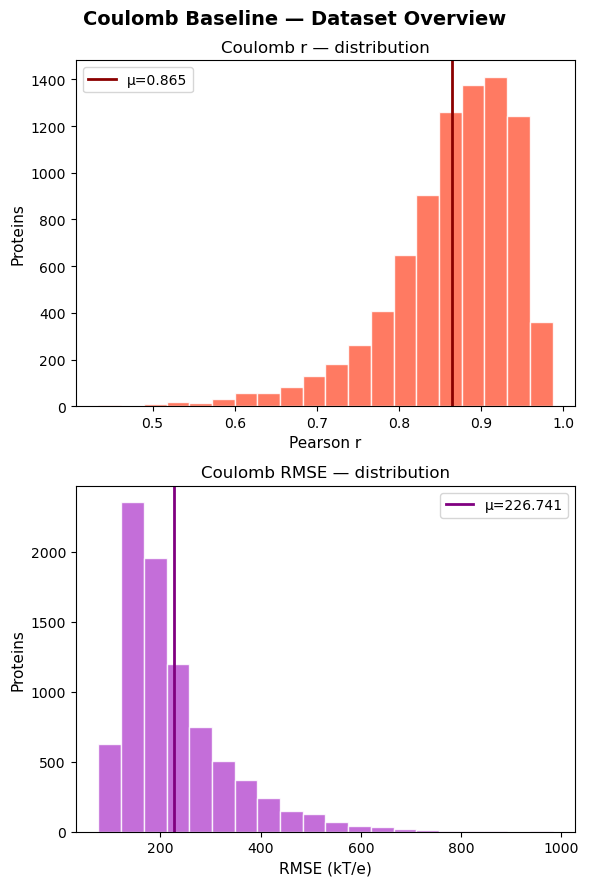

In [12]:
has_rbf  = "rbf_r" in df.columns and df["rbf_r"].notna().any()
has_rmse = "rbf_rmse" in df.columns and df["rbf_rmse"].notna().any()
ncols = 2 if has_rbf else 1
nrows = 2  # row 0: Pearson r   row 1: RMSE

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols + 1, 9), sharey=False)
if ncols == 1:
    axes = axes.reshape(-1, 1)  # ensure 2-D indexing

# ── Row 0: Pearson r ──────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(df["coulomb_r"], bins=20, color="tomato", alpha=0.85, edgecolor="white")
ax.axvline(df["coulomb_r"].mean(), color="darkred", lw=2,
           label=f"μ={df['coulomb_r'].mean():.3f}")
ax.set_xlabel("Pearson r", fontsize=11)
ax.set_ylabel("Proteins", fontsize=11)
ax.set_title("Coulomb r — distribution", fontsize=12)
ax.legend()

if has_rbf:
    ax = axes[0, 1]
    vr = df.dropna(subset=["rbf_r"])
    ax.scatter(vr["coulomb_r"], vr["rbf_r"], s=40, color="steelblue", alpha=0.7)
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
    ax.set_xlabel("Coulomb Pearson r", fontsize=11)
    ax.set_ylabel("RBF Pearson r", fontsize=11)
    ax.set_title("Per-protein: Coulomb vs RBF ceiling (r)", fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# ── Row 1: RMSE ───────────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.hist(df["coulomb_rmse"], bins=20, color="mediumorchid", alpha=0.85, edgecolor="white")
ax.axvline(df["coulomb_rmse"].mean(), color="purple", lw=2,
           label=f"μ={df['coulomb_rmse'].mean():.3f}")
ax.set_xlabel("RMSE (kT/e)", fontsize=11)
ax.set_ylabel("Proteins", fontsize=11)
ax.set_title("Coulomb RMSE — distribution", fontsize=12)
ax.legend()

if has_rmse:
    ax = axes[1, 1]
    vr = df.dropna(subset=["rbf_rmse"])
    ax.scatter(vr["coulomb_rmse"], vr["rbf_rmse"], s=40, color="mediumorchid", alpha=0.7)
    lim = max(vr["coulomb_rmse"].max(), vr["rbf_rmse"].max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.4)
    ax.set_xlabel("Coulomb RMSE (kT/e)", fontsize=11)
    ax.set_ylabel("RBF RMSE (kT/e)", fontsize=11)
    ax.set_title("Per-protein: Coulomb vs RBF ceiling (RMSE)", fontsize=12)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)

fig.suptitle("Coulomb Baseline — Dataset Overview", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [11]:
# ── Thesis comparison table ────────────────────────────────────────────────────
# Fill in GNN numbers from your test_metrics.json once models are evaluated.

comparison = [
    {"Model":    "Vacuum Coulomb",
     "r (mean)": df["coulomb_r"].mean(),
     "RMSE":     df["coulomb_rmse"].mean(),
     "Notes":    "physics floor — no dielectric shielding"},
    {"Model":    "PatchESPN (CNN)",
     "r (mean)": None,
     "RMSE":     None,
     "Notes":    "MaSIF-style patches — to be trained"},
    {"Model":    "DistanceESPN",
     "r (mean)": None,
     "RMSE":     None,
     "Notes":    "GNN mean-aggregation AQ"},
    {"Model":    "AttentionESPN",
     "r (mean)": None,
     "RMSE":     None,
     "Notes":    "GNN cross-attention AQ"},
    {"Model":    "RBF reconstruction",
     "r (mean)": df["rbf_r"].mean() if has_rbf else None,
     "RMSE":     df["rbf_rmse"].mean() if (has_rbf and "rbf_rmse" in df.columns) else None,
     "Notes":    "analytic ceiling from APBS samples"},
]

comp_df = pd.DataFrame(comparison)
display(comp_df)

,Model,r (mean),RMSE,Notes
0,Vacuum Coulomb,0.8648,226.7405,physics floor — no dielectric shielding
1,PatchESPN (CNN),NaN,NaN,MaSIF-style patches — to be trained
2,DistanceESPN,NaN,NaN,GNN mean-aggregation AQ
3,AttentionESPN,NaN,NaN,GNN cross-attention AQ
4,RBF reconstruction,NaN,NaN,analytic ceiling from APBS samples
